# 🚊 Мострансхакатон — baseline прогноза посадок в трамваи (ноябрь–декабрь 2025)

**Задача:** `boardings(route, date, hour)` на сетку 10 маршрутов × 61 день × 24 часа. Метрика: `WAPE-score = 1 − Σ|y−ŷ|/Σy`.

**Схема (см. `ML_IDEAS.md`, `EXTERNAL_DATA.md`):**
```
ŷ = Profile(route, тип_дня, час)          ← базовая модель ТОЛЬКО на основном датасете
    × K_calendar × K_weather × K_season    ← внешние данные = поправочные коэффициенты
    ⊕ LightGBM (модель 2)                  ← прямой многогоризонтный ML, обучен на 39 «точках прогноза» истории
```
Прогноз **прямой (direct)** на весь горизонт — без рекурсии, ошибка не накапливается.

**Валидация:** rolling-origin фолды, горизонт как в задаче (до 61 дня), только прошлые данные.

**Входные данные:**
* **датасет хакатона** — публичный Kaggle-датасет [`shotme/moscow-transport`](https://www.kaggle.com/datasets/shotme/moscow-transport) (структура как в `dataset.zip`, API-ключ не нужен). По умолчанию качаются только `labels/*` и `test_submission.csv` (~1.5 МБ); `KAGGLE_FULL_DOWNLOAD=True` — весь датасет с сырыми `train.csv`/`test.csv` (~10 ГБ);
* **внешние данные** — папка на Google Drive (`DRIVE_DATA_DIR`, по умолчанию `MyDrive/mostrans`):
```
MyDrive/mostrans/
└── external_data/   # calendar_2025.csv, weather_fact_hourly_2025.csv, weather_fcst_hourly_2025.csv, events_2025.csv
```
  Сабмиты сохраняются в `MyDrive/mostrans/submissions/`.

Запуск: `Runtime → Run all`. GPU (T4/A100) не обязателен — данные маленькие (~60k строк), всё считается на CPU за пару минут.

In [1]:
#@title ⚙️ Конфиг
# --- датасет хакатона: публичный Kaggle-датасет (ключ не нужен) ---------------------
KAGGLE_DATASET = "shotme/moscow-transport"             #@param {type:"string"}
KAGGLE_FULL_DOWNLOAD = False                           #@param {type:"boolean"}
# False — только labels + шаблон сабмита (~1.5 МБ, секунды); True — весь датасет с сырыми train/test (~10 ГБ)

# --- внешние данные (external_data/) и папка для сабмитов --------------------------
# папка на своём Google Drive: внутри external_data/, сюда же пишутся submissions/
DRIVE_DATA_DIR = "/content/drive/MyDrive/mostrans"     #@param {type:"string"}

SEED = 42
ROUTES = [1, 5, 7, 11, 12, 17, 25, 26, 28, 50]
FORECAST_START, FORECAST_END = "2025-11-01", "2025-12-31"

# Погода на горизонте прогноза. Решение проверяют в ПОТОКОВОМ режиме: в момент прогноза будущей погоды нет.
# "fcst" — архив прогнозов Open-Meteo, и только на первые WEATHER_HORIZON_DAYS дней горизонта (дальше K=1, нейтрально).
# "fact" — фактическая погода: утечка из будущего, только для анализа, НЕ для сабмита.
WEATHER_FOR_FORECAST = "fcst"                          #@param ["fcst", "fact"]
REGIME_REF_WEEKS = 12                                  # окно «нормальных» выходных до начала работ
WEATHER_HORIZON_DAYS = 7                               # на сколько дней вперёд реально известен прогноз погоды

# Экспертные коэффициенты (нет аналогов в истории) — те же «ручки», что будут в UI
K_WORKING_SATURDAY = 0.85   # рабочая суббота 01.11: будний профиль × K
K_PRE_NEW_YEAR = 0.92       # 29–30.12: будний профиль × K
K_SEASON = {11: 1.00, 12: 0.98}  # месячная поправка к уровню сен–окт (зима, предНГ)

# Маршрут 5: в истории нет. Анонс Дептранса до 01.11 — «запуск к концу 2025», факт — 17.12.2025 (t.me/DtRoad/55381).
# Сценарий: профиль маршрута-аналога из НАШЕГО датасета × ROUTE5_K. Опубликованное число поездок (40 тыс./нед.)
# не используем: это значение target из внешнего источника. ROUTE5_ENABLED=False → прогноз 0
ROUTE5_ENABLED = False                                 #@param {type:"boolean"}
ROUTE5_LAUNCH = "2025-12-17"
ROUTE5_ANALOG_ROUTE = 25                               # самый малый маршрут в данных
ROUTE5_K = 1.0

# Режимы маршрутов (внешний источник №4: ремонты путей). Данные, а не константы в коде: каждая запись —
# маршруты, дни, интервал и ссылки с датами публикации. Внутри интервала модель берёт текущий (урезанный) профиль,
# вне его — «нормальный» профиль выходных, восстановленный по истории до начала работ.
# EVENTS_MODE: "all" — все опубликованные новости (организаторы разрешили данные после 31.10.2025);
#              "strict" — только опубликованные до отсечки (для 31.10: окончание «до конца осени» = 30.11)
EVENTS_MODE = "all"                                    #@param ["all", "strict"]
REGIMES = [
    dict(name="Ремонт путей в Протопоповском пер.: по выходным 50 не ходит, 7 укорочен",
         routes=[7, 50], ptypes=["sat", "sun"], start="2025-09-06",
         start_published="2025-09-05", start_url="https://t.me/DtOperativno/22624",
         end_announced="2025-11-30", end_announced_published="2025-09-12",
         end_announced_url="https://newsvostok.ru/dlya-tramvaev-7-i-50-izmeneniya-po-vyhodnym-budut-dejstvovat-do-kontsa-oseni/",
         end_actual="2025-11-14", end_actual_published="2025-11-15", end_actual_url="https://t.me/DtOperativno/23565"),
]

def known_regimes(cutoff):
    # режимы и их границы, известные на момент прогноза (с учётом EVENTS_MODE)
    cutoff, out = pd.Timestamp(cutoff), []
    for rg in REGIMES:
        if pd.Timestamp(rg["start_published"]) > cutoff:
            continue                                      # о работах ещё не объявили
        if EVENTS_MODE == "all" or pd.Timestamp(rg["end_actual_published"]) <= cutoff:
            end = rg["end_actual"]
        elif pd.Timestamp(rg["end_announced_published"]) <= cutoff:
            end = rg["end_announced"]
        else:
            end = "2100-01-01"                            # срок неизвестен — режим продолжается
        out.append({**rg, "start": pd.Timestamp(rg["start"]), "end": pd.Timestamp(end)})
    return out

In [2]:
#@title 📦 Установка и импорты
import os, sys, io, time, json, zipfile, warnings, subprocess
from pathlib import Path
warnings.filterwarnings("ignore")

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", "lightgbm>=4.3", "kagglehub", "tqdm"], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from tqdm.auto import tqdm

np.random.seed(SEED)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)
print("lightgbm", lgb.__version__, "| pandas", pd.__version__, "| colab:", IN_COLAB)
try:
    print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
                         capture_output=True, text=True).stdout.strip() or "GPU: нет")
except Exception:
    print("GPU: нет (не требуется)")

lightgbm 4.6.0 | pandas 2.2.3 | colab: True
GPU: нет (не требуется)


In [3]:
#@title 📂 Подключение данных
import shutil, urllib.request
NEEDED = ["labels/labels_day_train.csv", "labels/labels_day_test.csv", "test_submission.csv"]

def kaggle_file(rel):
    # один файл публичного датасета без ключа: kagglehub, запасной вариант — прямой HTTP к Kaggle API
    try:
        import kagglehub
        return Path(kagglehub.dataset_download(KAGGLE_DATASET, path=rel))
    except Exception as e:
        print(f"kagglehub ({rel}): {type(e).__name__}: {e} → качаю напрямую")
    dst = Path("/content/kaggle_ds") / rel
    if not dst.exists():
        dst.parent.mkdir(parents=True, exist_ok=True)
        url = f"https://www.kaggle.com/api/v1/datasets/download/{KAGGLE_DATASET}/{rel}"
        tmp = dst.with_suffix(dst.suffix + ".part")
        with urllib.request.urlopen(url) as r, open(tmp, "wb") as f:
            shutil.copyfileobj(r, f)
        if zipfile.is_zipfile(tmp):                        # Kaggle иногда отдаёт файл в zip-обёртке
            with zipfile.ZipFile(tmp) as zf:
                dst.write_bytes(zf.read(zf.namelist()[0]))
            tmp.unlink()
        else:
            tmp.rename(dst)
    return dst

if os.environ.get("LOCAL_DATA_DIR"):                     # локальный прогон: dataset.zip читается без распаковки
    PROJECT_DIR = Path(os.environ["LOCAL_DATA_DIR"])
    _Z = zipfile.ZipFile(PROJECT_DIR / "dataset.zip")
    ds_open = lambda rel: _Z.open(rel)
    DS_DIR = None
else:
    # --- датасет с Kaggle
    if KAGGLE_FULL_DOWNLOAD:
        import kagglehub
        DS_DIR = Path(kagglehub.dataset_download(KAGGLE_DATASET))   # весь датасет, ~10 ГБ после распаковки
        DS_FILES = {rel: DS_DIR / rel for rel in NEEDED}
    else:
        DS_DIR = None
        DS_FILES = {rel: kaggle_file(rel) for rel in tqdm(NEEDED, desc="kaggle")}
    ds_open = lambda rel: open(DS_FILES[rel], "rb")
    # --- external_data/ и папка для сабмитов — Google Drive
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path(DRIVE_DATA_DIR)

EXT = PROJECT_DIR / "external_data"
OUT_DIR = PROJECT_DIR / "submissions"; OUT_DIR.mkdir(exist_ok=True, parents=True)
assert EXT.exists(), f"нет папки {EXT}"
print("PROJECT_DIR:", PROJECT_DIR, "| датасет:", DS_DIR or "только labels + шаблон")
print(sorted(p.name for p in EXT.iterdir()))

kaggle:   0%|          | 0/3 [00:00<?, ?it/s]


100%|██████████| 932k/932k [00:00<00:00, 50.7MB/s]



100%|██████████| 229k/229k [00:00<00:00, 25.3MB/s]



100%|██████████| 292k/292k [00:00<00:00, 20.2MB/s]


Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/mostrans | датасет: только labels + шаблон
['DtOperativno_events_2025.csv', 'DtOperativno_posts_raw.jsonl', 'DtOperativno_traffic_scores_2025.csv', 'build_external.py', 'calendar_2025.csv', 'deptrans_posts_raw.jsonl', 'effects_report.csv', 'effects_tg_report.csv', 'events_2025.csv', 'parse_deptrans_tg.py', 'traffic_scores_2025.csv', 'weather_archive_2025_hourly.json', 'weather_fact_hourly_2025.csv', 'weather_fcst_hourly_2025.csv', 'weather_hist_forecast_2025_hourly.json', 'xmlcalendar_ru_2025.xml', 'xmlcalendar_ru_2026.xml', 'yandex_traffic_collector.py', 'yandex_traffic_live.csv']


In [4]:
#@title 📥 Загрузка: labels, шаблон сабмита, внешние данные
parts = []
for p in tqdm(["train", "test"], desc="labels"):
    parts.append(pd.read_csv(ds_open(f"labels/labels_day_{p}.csv"), sep=";"))
lab = pd.concat(parts, ignore_index=True)
lab["date"] = pd.to_datetime(lab["date"])
template = pd.read_csv(ds_open("test_submission.csv"), sep=";")

# полная сетка route × date × hour на историю (пропуски = 0 посадок)
hist_dates = pd.date_range("2025-01-01", "2025-10-31")
grid = pd.MultiIndex.from_product([ROUTES, hist_dates, range(24)], names=["route", "date", "hour"]).to_frame(index=False)
df = grid.merge(lab, how="left", on=["route", "date", "hour"]).fillna({"boardings": 0})

cal = pd.read_csv(EXT / "calendar_2025.csv", sep=";", parse_dates=["date"])
w_fact = pd.read_csv(EXT / "weather_fact_hourly_2025.csv", sep=";", parse_dates=["date"])
w_fcst = pd.read_csv(EXT / "weather_fcst_hourly_2025.csv", sep=";", parse_dates=["date"])
events = pd.read_csv(EXT / "events_2025.csv", sep=";", dtype=str).fillna("")

print(f"labels: {len(lab):,} строк | сетка: {len(df):,} | заполнено нулями: {(len(df)-len(lab)):,}")
print(f"шаблон сабмита: {template.shape} | календарь: {cal.shape} | погода: {w_fact.shape} | события: {events.shape}")

labels:   0%|          | 0/2 [00:00<?, ?it/s]

labels: 57,551 строк | сетка: 72,960 | заполнено нулями: 15,409
шаблон сабмита: (14640, 4) | календарь: (365, 14) | погода: (8760, 11) | события: (634, 9)


## 🔎 EDA

In [5]:
#@title Маршруты: объём, покрытие, доля в WAPE
t = df.groupby("route").agg(total=("boardings", "sum"), nonzero_hours=("boardings", lambda s: (s > 0).sum()))
t["share_%"] = (100 * t.total / t.total.sum()).round(1)
display(t.sort_values("total", ascending=False)) if "display" in dir() else print(t)
print("⚠️ маршрут 5 в истории:", int(t.loc[5, "total"]), "посадок → прогноз 0 (возвращён только 17.12.2025, см. EXTERNAL_DATA.md)")

            total  nonzero_hours  share_%
route                                    
1       5122040.0           6204      8.6
5             0.0              0      0.0
7       6493684.0           6600     10.9
11      8942462.0           6416     15.0
12      9339231.0           6629     15.7
17     14099382.0           6677     23.6
25      1988187.0           5904      3.3
26      4879661.0           6592      8.2
28      2775255.0           6116      4.7
50      6027289.0           6413     10.1
⚠️ маршрут 5 в истории: 0 посадок → прогноз 0 (возвращён только 17.12.2025, см. EXTERNAL_DATA.md)


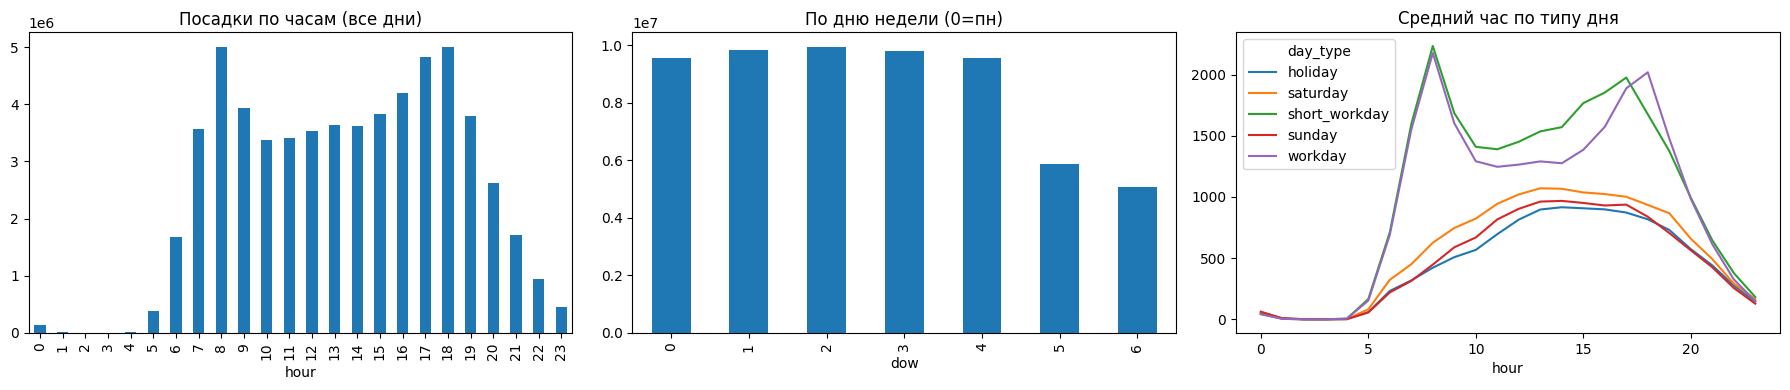

In [6]:
#@title Суточный и недельный профиль
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
d = df.merge(cal[["date", "dow", "day_type"]], on="date")
d.groupby("hour").boardings.sum().plot.bar(ax=ax[0], title="Посадки по часам (все дни)")
d.groupby("dow").boardings.sum().plot.bar(ax=ax[1], title="По дню недели (0=пн)")
(d.pivot_table(index="hour", columns="day_type", values="boardings", aggfunc="mean")
   .plot(ax=ax[2], title="Средний час по типу дня"))
plt.tight_layout(); plt.show()

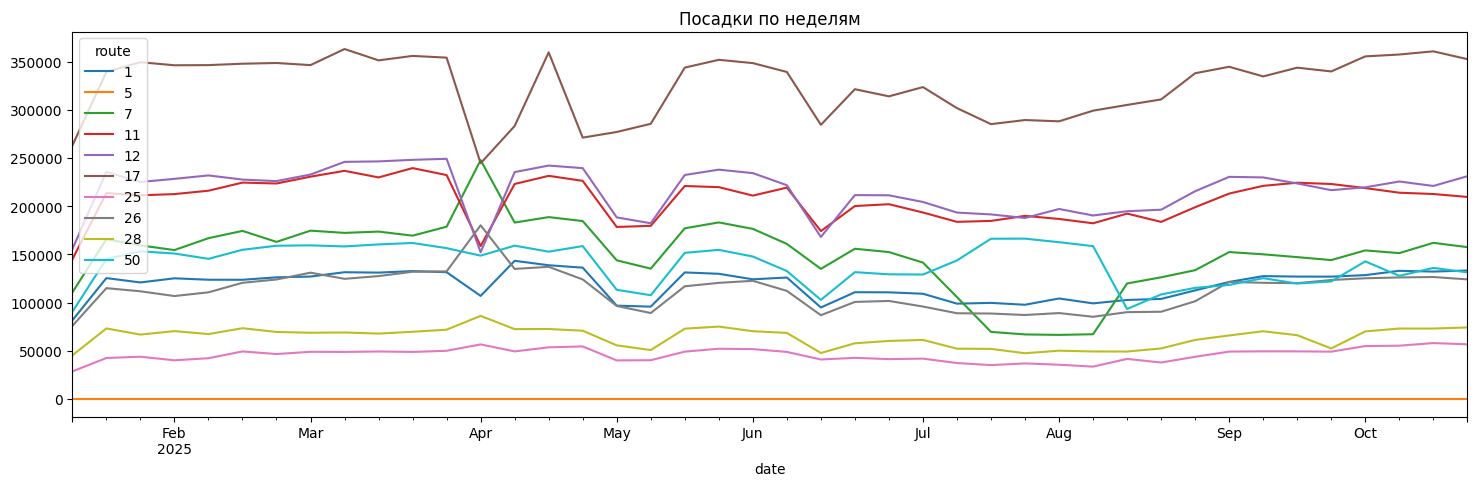

Месячные суммы, тыс.:
route     1    5      7       11      12      17     25     26     28     50
date                                                                        
1      464.0  0.0  615.0   818.0   878.0  1379.0  165.0  425.0  265.0  557.0
2      500.0  0.0  679.0   892.0   915.0  1389.0  185.0  479.0  279.0  617.0
3      563.0  0.0  763.0  1009.0  1058.0  1549.0  216.0  571.0  304.0  685.0
4      575.0  0.0  857.0   921.0   960.0  1269.0  229.0  610.0  325.0  672.0
5      504.0  0.0  712.0   881.0   941.0  1414.0  205.0  473.0  283.0  589.0
6      469.0  0.0  642.0   847.0   862.0  1341.0  184.0  429.0  253.0  527.0
7      460.0  0.0  403.0   839.0   877.0  1333.0  168.0  404.0  234.0  690.0
8      451.0  0.0  472.0   828.0   865.0  1362.0  171.0  398.0  230.0  533.0
9      547.0  0.0  649.0   951.0   974.0  1472.0  214.0  527.0  277.0  536.0
10     589.0  0.0  701.0   956.0  1010.0  1591.0  251.0  563.0  325.0  621.0

Отношение к марту (лето ↓, сентябрь–октябрь — плато):

In [7]:
#@title Динамика по неделям и маршрутам (сезонность, аномалии)
wk = df.set_index("date").groupby("route").boardings.resample("W").sum().unstack(0)
wk.iloc[1:-1].plot(figsize=(18, 5), title="Посадки по неделям"); plt.show()
mon = df.groupby([df.date.dt.month, "route"]).boardings.sum().unstack()
print("Месячные суммы, тыс.:"); print((mon / 1e3).round(0))
print("\nОтношение к марту (лето ↓, сентябрь–октябрь — плато):"); print((mon / mon.loc[3]).round(2))

In [8]:
#@title Аномальные дни (>±40% от медианы того же дня недели за 4 ПРОШЛЫЕ недели — без заглядывания вперёд)
def find_anomalies(data, cutoff=None):
    # причинная разметка: база дня — медиана того же дня недели за 4 предыдущие недели, данные только до cutoff
    d = data if cutoff is None else data[data.date <= pd.Timestamp(cutoff)]
    daily = d.groupby(["route", "date"]).boardings.sum().unstack(0)
    base = pd.concat([daily.shift(7 * k, freq="D") for k in (1, 2, 3, 4)]).groupby(level=0).median().reindex(daily.index)
    ratio = daily / base
    hol = CAL_ANOM.reindex(daily.index).is_holiday.values[:, None] == 1
    anom = ((ratio < 0.6) | (ratio > 1.4)) & ~hol
    s = anom.stack()
    return set((r, d) for d, r in s[s].index)

CAL_ANOM = cal.set_index("date")
anom_all = find_anomalies(df)
print("Аномальных (маршрут, день), не праздники:", len(anom_all))
print(pd.Series([r for r, _ in anom_all]).value_counts().sort_index().rename("дней").to_frame().T)

# для EDA ниже (не для модели): медиана того же дня недели ±4 нед.
daily = df.groupby(["route", "date"]).boardings.sum().unstack(0)
c = cal.set_index("date").reindex(daily.index)
def same_dow_median(s):
    out = pd.Series(index=s.index, dtype=float)
    for d0 in s.index:
        nb = [d0 + pd.Timedelta(weeks=k) for k in (-4, -3, -2, -1, 1, 2, 3, 4)]
        out[d0] = s.reindex(nb).median()
    return out

# смена режима: доля выходных в объёме маршрута по месяцам (маршрут 50 с сентября ходит только по будням)
we = df.assign(we=df.date.dt.dayofweek >= 5).groupby([df.date.dt.month, "route", "we"]).boardings.sum().unstack()
print("\nДоля выходных в объёме, %:"); print((100 * we[True] / we.sum(1)).unstack().round(1))

Аномальных (маршрут, день), не праздники: 200
      1   7   11  12  17  25  26  28  50
дней  12  51  12  11  17  17  20  16  44

Доля выходных в объёме, %:
route    1   5     7     11    12    17    25    26    28    50
date                                                           
1      15.2 NaN  18.8  18.6  17.2  21.0  19.8  18.5  17.6  13.9
2      15.4 NaN  18.4  18.2  17.0  21.6  18.9  17.2  18.3  12.9
3      18.3 NaN  22.0  22.6  20.3  25.7  24.9  21.4  21.6  15.0
4      14.4 NaN  16.3  17.9  16.6   8.3  20.5  17.0  17.0  13.5
5      16.3 NaN  19.5  21.3  18.5  22.0  23.8  19.6  20.5  15.2
6      16.6 NaN  19.3  21.1  17.5  21.7  22.9  20.0  19.9  14.7
7      14.4 NaN  16.8  18.8  16.4  19.0  20.8  17.5  18.4  15.9
8      18.5 NaN  20.7  25.5  21.8  25.7  29.2  23.4  23.4  20.9
9      13.4 NaN  11.0  19.5  17.0  20.1  21.5  17.4  18.3   0.6
10     14.0 NaN  11.1  18.1  16.2  20.1  20.6  16.1  16.5   1.0


In [9]:
#@title Эффект календаря и погоды (контроль того, что поправки нужны)
tot = daily.sum(1); tot_base = daily.apply(same_dow_median).sum(1); r = tot / tot_base
print("Праздник в будни:", r[(c.is_holiday == 1) & (c.dow < 5)].mean().round(3),
      "| обычный будний:", r[(c.is_day_off == 0)].mean().round(3))
wd = w_fact.groupby("date").agg(temp=("temperature_2m", "mean"), precip=("precipitation", "sum"))
x = pd.concat([r.rename("ratio"), wd.reindex(r.index)], axis=1)[(c.is_day_off == 0).values]
print("corr(ratio, temp) =", x.corr().loc["ratio", "temp"].round(3), "| corr(ratio, precip) =", x.corr().loc["ratio", "precip"].round(3))

Праздник в будни: 0.452 | обычный будний: 1.002
corr(ratio, temp) = 0.025 | corr(ratio, precip) = -0.449


## 🧱 Модель 1: профиль × поправки

* **Профиль** `S[route, ptype, hour] = Level[route, ptype] × Shape[route, ptype, hour]`:
  * `Level` — суточный объём за последние `level_weeks` «чистых» недель (уровень быстро дрейфует, нужно свежее окно);
  * `Shape` — доля часа в сутках за последние `n_weeks` недель (форма стабильна, длинное окно гасит шум).
  «Чистые» дни — без праздников, аномалий и, опционально, летних каникул.
  `ptype`: `mon_thu / fri / sat / sun`. Праздник → профиль `sun` × `K_holiday`; рабочая суббота → `mon_thu` × `K_WORKING_SATURDAY`.
* **K_holiday, K_short** — оцениваются по истории до отсечки.
* **K_weather** — регрессия `log(факт/профиль)` на погоду по будням обучающего окна; на горизонте — погода `WEATHER_FOR_FORECAST`.

In [10]:
#@title Функции: метрика, типы дней, признаки
def wape_score(y, p):
    y = np.asarray(y, float); p = np.asarray(p, float)
    return max(0.0, 1 - np.abs(y - p).sum() / y.sum())

CAL = cal.set_index("date")
def ptype_of(dates, use_calendar=True):
    c = CAL.loc[dates]
    pt = np.select([c.dow <= 3, c.dow == 4, c.dow == 5], ["mon_thu", "fri", "sat"], "sun")
    if use_calendar:  # праздник -> профиль воскресенья, рабочая суббота -> будни
        pt = np.where(c.is_holiday == 1, "sun", pt)
        pt = np.where(c.is_working_weekend == 1, "mon_thu", pt)
    return pd.Series(pt, index=dates)

def daily_weather(w):
    g = w.groupby("date")
    return pd.DataFrame({"temp": g.temperature_2m.mean(), "precip": g.precipitation.sum(),
                         "snow": g.snowfall.sum(), "snow_depth": g.snow_depth.mean()})
WD_FACT, WD_FCST = daily_weather(w_fact), daily_weather(w_fcst)
WD_FUT = WD_FACT if WEATHER_FOR_FORECAST == "fact" else WD_FCST   # погода, подаваемая в прогноз (и в валидацию)

In [11]:
#@title Класс ProfileModel
class ProfileModel:
    def __init__(self, n_weeks=6, agg="median", exclude_summer=True, use_weather=True, use_calendar=True, level_weeks=None,
                 drop_anomalies=False):
        self.n_weeks, self.agg, self.exclude_summer = n_weeks, agg, exclude_summer
        self.level_weeks = level_weeks or n_weeks        # None → уровень и форма по одному окну (старый профиль)
        self.use_weather, self.use_calendar = use_weather, use_calendar
        self.drop_anomalies = drop_anomalies           # False: после смены режима «аномалии» = новая норма (маршрут 50)

    def _clean_days(self, cutoff):
        c = CAL.loc[:cutoff]
        ok = (c.is_holiday == 0) & (c.is_short_workday == 0) & (c.is_working_weekend == 0)
        if self.exclude_summer:
            ok &= ~c.school_holiday_name.fillna("").str.contains("летние")
        days = c.index[ok][-max(self.n_weeks, self.level_weeks) * 7:]
        return days

    def fit(self, data, cutoff):
        cutoff = pd.Timestamp(cutoff)
        self.cutoff = cutoff
        all_days = self._clean_days(cutoff)
        days = all_days[-self.n_weeks * 7:]                # окно формы
        lvl_days = all_days[-self.level_weeks * 7:]        # окно уровня
        tr = data[data.date.isin(all_days)].copy()
        if self.drop_anomalies:                             # разметка только по данным до отсечки
            aset = find_anomalies(data, cutoff)
            tr = tr[[(r, d) not in aset for r, d in zip(tr.route, tr.date)]]
        tr["ptype"] = ptype_of(pd.DatetimeIndex(tr.date)).values
        shape = tr[tr.date.isin(days)].groupby(["route", "ptype", "hour"]).boardings.agg(self.agg)
        shape = shape / shape.groupby(level=["route", "ptype"]).transform("sum")
        level = (tr[tr.date.isin(lvl_days)].groupby(["route", "ptype", "date"]).boardings.sum()
                   .groupby(level=["route", "ptype"]).agg(self.agg))
        self.S = (shape * level.reindex(shape.index.droplevel("hour")).values).fillna(0)
        self.level = level
        self.regimes = [self._normal_profile(data, rg) for rg in known_regimes(cutoff)]
        # --- K по календарю: факт / профиль на праздниках и сокращённых днях до отсечки
        hist = data[data.date <= cutoff]
        self.K_holiday, self.K_short = 1.0, 1.0
        if self.use_calendar:
            self.K_holiday = self._k(hist, CAL.index[(CAL.is_holiday == 1) & (CAL.index <= cutoff)], default=0.82)
            self.K_short = self._k(hist, CAL.index[(CAL.is_short_workday == 1) & (CAL.dow < 5) & (CAL.index <= cutoff)], default=1.0)
        # --- K по погоде: OLS на будних днях обучающего окна (факт погоды)
        self.beta = np.zeros(3); self.w_mu = WD_FACT.loc[days, ["temp", "precip", "snow"]].mean()
        if self.use_weather:
            wd = [d for d in days if CAL.loc[d, "dow"] < 5]
            y = hist[hist.date.isin(wd)].groupby("date").boardings.sum()
            p = self._raw(pd.DatetimeIndex(wd)).groupby("date").pred.sum()
            X = WD_FACT.loc[wd, ["temp", "precip", "snow"]] - self.w_mu
            yy = np.log((y / p).clip(0.5, 1.5)).loc[wd]
            A = np.c_[np.ones(len(X)), X.values]
            coef = np.linalg.lstsq(A, yy.values, rcond=None)[0]
            self.beta = np.clip(coef[1:], -0.02, 0.02)   # не более ±2%/ед.: защита от переобучения
            # признак без вариации в окне (снег в сен–окт) не оценить — коэффициент 0, а не мусор на границе клипа
            self.beta[((WD_FACT.loc[wd, ["temp", "precip", "snow"]].abs() > 0.1).sum() < 5).values] = 0.0
        return self

    def _normal_profile(self, data, rg):
        # профиль вне режима: текущий будний уровень × (выходные / будни) и форма суток по чистым дням до начала работ
        c = CAL.loc[:rg["start"] - pd.Timedelta(days=1)]
        ok = (c.is_holiday == 0) & (c.is_short_workday == 0) & (c.is_working_weekend == 0)
        ok &= ~c.school_holiday_name.fillna("").str.contains("летние")
        ref = data[data.date.isin(c.index[ok][-REGIME_REF_WEEKS * 7:]) & data.route.isin(rg["routes"])].copy()
        ref["ptype"] = ptype_of(pd.DatetimeIndex(ref.date)).values
        day_lvl = ref.groupby(["route", "ptype", "date"]).boardings.sum().groupby(level=["route", "ptype"]).median()
        ratio = day_lvl / day_lvl.xs("mon_thu", level="ptype").reindex(day_lvl.index.get_level_values("route")).values
        shape = ref.groupby(["route", "ptype", "hour"]).boardings.median()
        shape = shape / shape.groupby(level=["route", "ptype"]).transform("sum")
        idx = shape.index.droplevel("hour")
        cur_weekday = self.level.xs("mon_thu", level="ptype").reindex(idx.get_level_values("route")).values
        S_norm = shape * ratio.reindex(idx).values * cur_weekday
        rg["ratio"] = ratio
        rg["S_normal"] = S_norm[S_norm.index.get_level_values("ptype").isin(rg["ptypes"])]
        return rg

    def _k(self, hist, days, default):
        days = [d for d in days if d in set(hist.date)]
        if not days:
            return default
        y = hist[hist.date.isin(days)].groupby("date").boardings.sum()
        p = self._raw(pd.DatetimeIndex(days), calendar=False).groupby("date").pred.sum()
        return float(np.median((y / p).replace([np.inf, -np.inf], np.nan).dropna())) if len(p) else default

    def _raw(self, dates, calendar=True):
        g = pd.MultiIndex.from_product([ROUTES, dates, range(24)], names=["route", "date", "hour"]).to_frame(index=False)
        g["ptype"] = ptype_of(pd.DatetimeIndex(g.date), use_calendar=self.use_calendar or not calendar).values
        g["pred"] = self.S.reindex(pd.MultiIndex.from_frame(g[["route", "ptype", "hour"]])).fillna(0).values
        for rg in getattr(self, "regimes", []):
            # вне интервала работ — нормальный профиль (в обучающем окне выходные могли быть урезаны режимом)
            m = (g.route.isin(rg["routes"]) & g.ptype.isin(rg["ptypes"]) & ~g.date.between(rg["start"], rg["end"])).values
            if m.any():
                g.loc[m, "pred"] = rg["S_normal"].reindex(pd.MultiIndex.from_frame(g.loc[m, ["route", "ptype", "hour"]])).fillna(0).values
        return g

    def predict(self, dates, weather=None):
        dates = pd.DatetimeIndex(dates)
        g = self._raw(dates)
        c = CAL.loc[g.date]
        k = np.ones(len(g))
        if self.use_calendar:
            k = np.where(c.is_holiday.values == 1, self.K_holiday, k)
            k = np.where((c.is_short_workday.values == 1) & (c.dow.values < 5), k * self.K_short, k)
            k = np.where(c.is_working_weekend.values == 1, k * K_WORKING_SATURDAY, k)
        if self.use_weather and weather is not None:
            X = weather.reindex(g.date)[["temp", "precip", "snow"]].fillna(self.w_mu) - self.w_mu
            # дальше горизонта прогноза погоды — нейтрально (в момент прогноза этих данных нет)
            X[(g.date > self.cutoff + pd.Timedelta(days=WEATHER_HORIZON_DAYS)).values] = 0.0
            k = k * np.exp(np.clip(X.values @ self.beta, -0.1, 0.1))
        g["pred"] = g.pred * k
        return g[["route", "date", "hour", "pred"]]

In [12]:
#@title Фолды валидации
FOLDS = [  # (имя, отсечка, начало, конец)
    ("F1 авг→сен–окт (61д)", "2025-08-31", "2025-09-01", "2025-10-31"),
    ("F2 сен→окт (31д)",     "2025-09-30", "2025-10-01", "2025-10-31"),
    ("F4 сер.сен→окт (47д)", "2025-09-14", "2025-09-15", "2025-10-31"),
    ("F5 сер.окт→окт (19д)", "2025-10-12", "2025-10-13", "2025-10-31"),
    ("F3 мар→апр–май (61д, праздники)", "2025-03-31", "2025-04-01", "2025-05-31"),
]
def evaluate(make_model, folds=FOLDS, verbose=False, return_preds=False):
    res, preds = {}, {}
    for name, cut, a, b in folds:
        m = make_model().fit(df, cut)
        dates = pd.date_range(a, b)
        p = m.predict(dates, weather=WD_FUT)
        y = df[df.date.isin(dates)].merge(p, on=["route", "date", "hour"])
        res[name] = wape_score(y.boardings, y.pred)
        preds[name] = y
        if verbose:
            print(f"  {name}: WAPE-score = {res[name]:.4f}")
    res["mean"] = np.mean(list(res.values()))
    return (res, preds) if return_preds else res

print("Seasonal naive (профиль 6 нед., без поправок):")
r0 = evaluate(lambda: ProfileModel(6, use_weather=False, use_calendar=False), verbose=True)
print(f"  mean = {r0['mean']:.4f}")

Seasonal naive (профиль 6 нед., без поправок):
  F1 авг→сен–окт (61д): WAPE-score = 0.8800
  F2 сен→окт (31д): WAPE-score = 0.9069
  F4 сер.сен→окт (47д): WAPE-score = 0.8885
  F5 сер.окт→окт (19д): WAPE-score = 0.9112
  F3 мар→апр–май (61д, праздники): WAPE-score = 0.8177
  mean = 0.8809


In [13]:
#@title Подбор гиперпараметров профиля (прогресс-бар + метрика по ходу)
import itertools
# n_weeks — окно формы суток, level_weeks — окно уровня
space = list(itertools.product([8, 12, 16], [2, 3, 4], ["median", "mean"], [True], [False, True]))
rows = []
pbar = tqdm(space, desc="grid")
for n, lw, agg, es, da in pbar:
    r = evaluate(lambda: ProfileModel(n, agg, es, use_weather=False, use_calendar=True, level_weeks=lw, drop_anomalies=da))
    rows.append({"n_weeks": n, "level_weeks": lw, "agg": agg, "exclude_summer": es, "drop_anomalies": da, **r})
    best = max(rows, key=lambda x: x["mean"])
    pbar.set_postfix(best=f"{best['mean']:.4f}", cur=f"{r['mean']:.4f}")
grid_res = pd.DataFrame(rows).sort_values("mean", ascending=False)
print(grid_res.head(10).round(4).to_string(index=False))
BEST = grid_res.iloc[0][["n_weeks", "level_weeks", "agg", "exclude_summer", "drop_anomalies"]].to_dict()
BEST["n_weeks"] = int(BEST["n_weeks"]); BEST["level_weeks"] = int(BEST["level_weeks"]); BEST["exclude_summer"] = bool(BEST["exclude_summer"]); BEST["drop_anomalies"] = bool(BEST["drop_anomalies"])
print("BEST:", BEST)

grid:   0%|          | 0/36 [00:00<?, ?it/s]

 n_weeks  level_weeks    agg  exclude_summer  drop_anomalies  F1 авг→сен–окт (61д)  F2 сен→окт (31д)  F4 сер.сен→окт (47д)  F5 сер.окт→окт (19д)  F3 мар→апр–май (61д, праздники)   mean
      16            3 median            True           False                0.8897            0.9081                0.9076                0.9124                           0.8512 0.8938
      12            3 median            True           False                0.8897            0.9063                0.9066                0.9118                           0.8512 0.8931
      16            2   mean            True           False                0.8871            0.9033                0.9071                0.9149                           0.8528 0.8930
      16            3   mean            True           False                0.8888            0.9058                0.9042                0.9125                           0.8537 0.8930
      16            2 median            True           False               

In [14]:
#@title Ablation внешних поправок (для критерия 2а)
abl = {}
for name, kw in tqdm([("profile only", dict(use_weather=False, use_calendar=False)),
                      ("+ calendar", dict(use_weather=False, use_calendar=True)),
                      ("+ calendar + weather", dict(use_weather=True, use_calendar=True))], desc="ablation"):
    abl[name] = evaluate(lambda: ProfileModel(**{**BEST, **kw}))
abl = pd.DataFrame(abl).T.round(4)
print(abl.to_string())
m_tmp = ProfileModel(**BEST).fit(df, "2025-10-31")
print(f"\nK_holiday={m_tmp.K_holiday:.3f}  K_short={m_tmp.K_short:.3f}  beta_weather(temp,precip,snow)={np.round(m_tmp.beta, 4)}")

ablation:   0%|          | 0/3 [00:00<?, ?it/s]

                      F1 авг→сен–окт (61д)  F2 сен→окт (31д)  F4 сер.сен→окт (47д)  F5 сер.окт→окт (19д)  F3 мар→апр–май (61д, праздники)    mean
profile only                        0.8897            0.9081                0.9076                0.9124                           0.8145  0.8865
+ calendar                          0.8897            0.9081                0.9076                0.9124                           0.8512  0.8938
+ calendar + weather                0.8894            0.9083                0.9076                0.9104                           0.8508  0.8933

K_holiday=0.896  K_short=0.997  beta_weather(temp,precip,snow)=[-0.0018 -0.0031  0.    ]


## 🤖 Модель 2: прямой многогоризонтный LightGBM, обученный в потоковой постановке

Как модель будет работать в проде: в момент `t` она видит только данные до `t` и прогнозирует сразу весь горизонт `t+1 … t+61` (direct, без рекурсии).
Так же она и **обучается**: в истории через каждые `ORIGIN_STEP_DAYS` дней ставится «точка прогноза» `t`. Признаки считаются строго по данным до `t`,
цель — фактические посадки через 1…61 день. Одна глобальная модель учится на **~570 тыс. примеров** (39 точек × 61 день × 9 маршрутов × 24 часа)
вместо ~60 тыс. строк labels. Это и есть честное расширение обучающей выборки.

* **Признаки** (все известны в момент `t`): маршрут, час, день недели, тип дня, праздник / сокращённый / рабочая суббота, дни до НГ;
  свежесть уровня (будни за 5/10/20 дней к 30); тот же час в тот же день недели неделю назад и в среднем за 4 недели; флаг режима маршрута;
  прогноз модели 1 (профиля) как базовая линия.
* **Цель** — отношение `факт / профиль` с весом `профиль`. L1 на таком отношении — это ровно WAPE по посадкам.
* Летние недели (отпуска, закрытие участков) из целей исключены: на ноябрь–декабрь эта динамика не переносится.
* **Ансамбль** модели 1 и модели 2 — вес подбирается по фолдам.

In [15]:
#@title Модель 2: признаки из точки прогноза и обучающая выборка
ORIGIN_STEP_DAYS = 7         # шаг точек прогноза в истории
ML_ROUNDS = 500
ML_FEATS = ["route", "hour", "dow", "ptype", "is_holiday", "is_short_workday", "is_working_weekend", "is_day_off",
            "pre_new_year_week", "days_to_ny", "lvl_wd5", "lvl_wd10", "lvl_wd20", "lag_w1", "lag_m4", "in_regime"]
ML_PARAMS = dict(objective="l1", learning_rate=0.03, num_leaves=63, min_data_in_leaf=200, feature_fraction=0.8,
                 bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0, seed=SEED, verbose=-1, num_threads=os.cpu_count(),
                 deterministic=True, force_col_wise=True)   # детерминизм нужен тесту на утечку
ROUTE_DTYPE = pd.CategoricalDtype(sorted(r for r in ROUTES if r != 5))
SUMMER_DAYS = set(CAL.index[CAL.school_holiday_name.fillna("").str.contains("летние")])
PTYPE_CODE = {"mon_thu": 0, "fri": 1, "sat": 2, "sun": 3}

def make_pivots(data):
    Y = data.pivot_table(index=["route", "date"], columns="hour", values="boardings", aggfunc="sum").reindex(columns=range(24)).fillna(0)
    return Y, Y.sum(1)

def origin_frame(data, t, end, piv):
    # признаки для прогноза из точки t на даты t+1…end; используются только данные <= t
    t = pd.Timestamp(t)
    dates = pd.date_range(t + pd.Timedelta(days=1), pd.Timestamp(end))
    hist = data[data.date <= t]
    Y, DAILY = piv
    pm = ProfileModel(**BEST).fit(hist, t)
    f = pm.predict(dates, weather=WD_FUT).rename(columns={"pred": "prof"})
    c = CAL.loc[f.date]
    for col in ["dow", "is_holiday", "is_short_workday", "is_working_weekend", "is_day_off", "pre_new_year_week"]:
        f[col] = c[col].values
    f["days_to_ny"] = np.clip(c.days_to_new_year.values, 0, 90)
    f["ptype"] = ptype_of(pd.DatetimeIndex(f.date)).map(PTYPE_CODE).values
    d = DAILY[DAILY.index.get_level_values("date").to_series().between(t - pd.Timedelta(days=55), t).values].unstack(0)
    wd = d[d.index.dayofweek < 5]
    for k in (5, 10, 20):
        f[f"lvl_wd{k}"] = f.route.map(wd.tail(k).mean() / wd.tail(30).mean().replace(0, np.nan)).values
    back = ((t.dayofweek - f.date.dt.dayofweek) % 7).values
    last_same = t - pd.to_timedelta(back, unit="D")                  # последний такой же день недели <= t
    rows, hours = np.arange(len(f)), f.hour.values
    lag = lambda k: Y.reindex(pd.MultiIndex.from_arrays([f.route.values, last_same - pd.Timedelta(days=7 * k)])).values[rows, hours]
    f["lag_w1"] = lag(0)
    f["lag_m4"] = np.nanmean(np.vstack([lag(k) for k in range(4)]), axis=0)
    for col in ["lag_w1", "lag_m4"]:
        f[col] = f[col] / f.prof.clip(lower=1)
    f["in_regime"] = 0
    for rg in pm.regimes:
        f.loc[f.route.isin(rg["routes"]) & f.date.between(rg["start"], rg["end"]) & (f.ptype >= 2), "in_regime"] = 1
    return f, pm

ORIGINS = pd.date_range("2025-02-01", "2025-10-30", freq=f"{ORIGIN_STEP_DAYS}D")

def build_train(data, cutoff, cache=None, piv=None):
    # обучающая выборка на отсечку: точки прогноза < cutoff, цели <= cutoff, без летних недель
    cutoff = pd.Timestamp(cutoff)
    parts = []
    for o in ORIGINS[ORIGINS < cutoff]:
        fr = cache[o] if cache is not None else origin_frame(data, o, o + pd.Timedelta(days=61), piv)[0]
        parts.append(fr[(fr.date <= cutoff) & ~fr.date.isin(SUMMER_DAYS)])
    tr = pd.concat(parts).merge(data[["route", "date", "hour", "boardings"]], on=["route", "date", "hour"])
    return tr[tr.prof > 1]

def fit_ml(tr):
    X = tr[ML_FEATS].copy(); X["route"] = X.route.astype(ROUTE_DTYPE)
    return lgb.train(ML_PARAMS, lgb.Dataset(X, (tr.boardings / tr.prof).clip(0, 3), weight=tr.prof), ML_ROUNDS)

def predict_ml(model, fr):
    X = fr[ML_FEATS].copy(); X["route"] = X.route.astype(ROUTE_DTYPE)
    return np.where(fr.prof.values > 1, fr.prof.values * np.clip(model.predict(X), 0.3, 2.0), fr.prof.values)

PIV_ALL = make_pivots(df)
# точки прогноза считаются один раз: каждая использует только данные до себя (это проверяет тест на утечку ниже)
ORIGIN_CACHE = {o: origin_frame(df, o, o + pd.Timedelta(days=61), PIV_ALL)[0] for o in tqdm(ORIGINS, desc="точки прогноза")}
print(f"точек прогноза: {len(ORIGINS)} | строк-примеров: {sum(len(v) for v in ORIGIN_CACHE.values()):,} (labels: {len(lab):,})")

точки прогноза:   0%|          | 0/39 [00:00<?, ?it/s]

точек прогноза: 39 | строк-примеров: 570,960 (labels: 57,551)


In [16]:
#@title Валидация модели 2 и ансамбля по фолдам
rows = []
for name, cut, a, b in tqdm(FOLDS, desc="folds"):
    booster = fit_ml(build_train(df, cut, cache=ORIGIN_CACHE))
    fr, _ = origin_frame(df, cut, b, PIV_ALL)
    y = df[df.date.isin(pd.date_range(a, b))].merge(fr, on=["route", "date", "hour"])
    y["lgb"] = predict_ml(booster, y)
    r = {"fold": name, "profile": wape_score(y.boardings, y.prof), "lgb": wape_score(y.boardings, y.lgb)}
    for wgt in (0.3, 0.5, 0.7):
        r[f"blend{wgt}"] = wape_score(y.boardings, (1 - wgt) * y.prof + wgt * y.lgb)
    rows.append(r)
    print(f"{name}: profile={r['profile']:.4f}  lgb={r['lgb']:.4f}  blend0.3={r['blend0.3']:.4f}")
cv = pd.DataFrame(rows).set_index("fold")
cv.loc["mean"] = cv.mean()
print(cv.round(4).to_string())
# ансамбль всегда включает ML-модель (вес >= 0.3); конкретный вес — по среднему CV
BLEND_W = float(max([0.3, 0.5, 0.7, 1.0], key=lambda w: cv.loc["mean", {1.0: "lgb"}.get(w, f"blend{w}")]))
print("Вес модели 2 (LightGBM) в ансамбле:", BLEND_W, f"| CV ансамбля {cv.loc['mean', {1.0: 'lgb'}.get(BLEND_W, f'blend{BLEND_W}')]:.4f} против профиля {cv.loc['mean', 'profile']:.4f}")
imp = pd.Series(booster.feature_importance("gain"), index=ML_FEATS).sort_values(ascending=False)
print("\nВажность признаков модели 2 (gain, %):"); print((100 * imp / imp.sum()).round(1).to_string())

folds:   0%|          | 0/5 [00:00<?, ?it/s]

F1 авг→сен–окт (61д): profile=0.8894  lgb=0.8642  blend0.3=0.8880
F2 сен→окт (31д): profile=0.9083  lgb=0.8996  blend0.3=0.9083
F4 сер.сен→окт (47д): profile=0.9076  lgb=0.8975  blend0.3=0.9078
F5 сер.окт→окт (19д): profile=0.9104  lgb=0.9097  blend0.3=0.9138
F3 мар→апр–май (61д, праздники): profile=0.8508  lgb=0.8390  blend0.3=0.8496
                                 profile     lgb  blend0.3  blend0.5  blend0.7
fold                                                                          
F1 авг→сен–окт (61д)              0.8894  0.8642    0.8880    0.8836    0.8770
F2 сен→окт (31д)                  0.9083  0.8996    0.9083    0.9070    0.9047
F4 сер.сен→окт (47д)              0.9076  0.8975    0.9078    0.9062    0.9035
F5 сер.окт→окт (19д)              0.9104  0.9097    0.9138    0.9144    0.9136
F3 мар→апр–май (61д, праздники)   0.8508  0.8390    0.8496    0.8476    0.8448
mean                              0.8933  0.8820    0.8935    0.8918    0.8887
Вес модели 2 (LightGBM) в ансам

route           1    5       7       11      12      17     25     26     28      50
WAPE-score   0.919  NaN   0.829   0.904   0.908   0.933  0.853  0.917  0.861   0.763
share_err_%  6.560  0.0  16.414  12.956  12.907  14.578  4.838  6.386  5.951  19.410


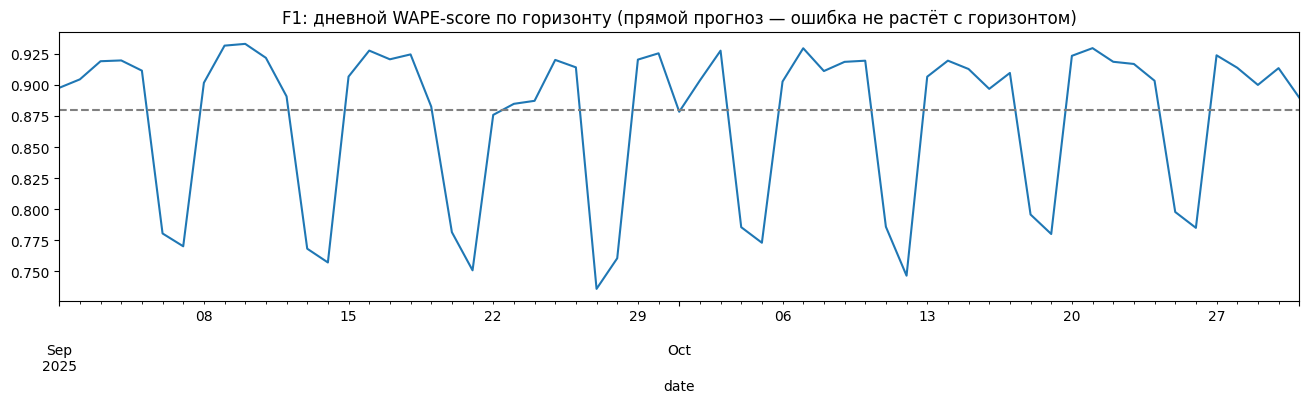

In [17]:
#@title Ошибка по маршрутам и по дням горизонта (устойчивость многошагового прогноза)
_, P = evaluate(lambda: ProfileModel(**BEST), folds=FOLDS[:1], return_preds=True)
y = P[FOLDS[0][0]]
by_route = y.groupby("route").apply(lambda g: pd.Series({"WAPE-score": wape_score(g.boardings, g.pred) if g.boardings.sum() else np.nan,
                                                          "share_err_%": 100 * np.abs(g.boardings - g.pred).sum() / np.abs(y.boardings - y.pred).sum()}))
print(by_route.round(3).T)
dd = y.groupby("date").apply(lambda g: np.abs(g.boardings - g.pred).sum() / g.boardings.sum())
ax = (1 - dd).plot(figsize=(16, 3.5), title="F1: дневной WAPE-score по горизонту (прямой прогноз — ошибка не растёт с горизонтом)")
ax.axhline(0.88, ls="--", c="gray"); plt.show()

## 🚀 Финальный прогноз на ноябрь–декабрь 2025 и сабмит

In [18]:
#@title Полный пайплайн прогноза: данные до отсечки → прогноз на горизонт
def route5_pred(pm, dates):
    # дата запуска — событие из новостей; уровень и форма — маршрут-аналог из нашего датасета
    S = pm.S.xs(ROUTE5_ANALOG_ROUTE, level="route") * ROUTE5_K
    g = pd.MultiIndex.from_product([[5], pd.DatetimeIndex(dates), range(24)], names=["route", "date", "hour"]).to_frame(index=False)
    g["ptype"] = ptype_of(pd.DatetimeIndex(g.date)).values
    g["pred"] = S.reindex(pd.MultiIndex.from_frame(g[["ptype", "hour"]])).fillna(0).values
    g.loc[g.date < pd.Timestamp(ROUTE5_LAUNCH), "pred"] = 0.0
    return g[["route", "date", "hour", "pred"]]

def apply_knobs(base, pm):
    # экспертные поправки без аналогов в истории (те же ручки — в UI)
    p = base.copy()
    c = CAL.loc[p.date]
    p.loc[c.pre_new_year_week.values.astype(bool) & (c.is_day_off.values == 0) & (p.date >= "2025-12-29").values, "pred"] *= K_PRE_NEW_YEAR
    p["pred"] *= p.date.dt.month.map(K_SEASON).fillna(1.0).values
    p = p[p.route != 5]
    r5 = route5_pred(pm, sorted(base.date.unique()))
    if not ROUTE5_ENABLED:
        r5["pred"] = 0.0
    return pd.concat([p, r5], ignore_index=True).sort_values(["route", "date", "hour"], ignore_index=True)

def full_forecast(data, cutoff, dates, cache=None):
    # ровно то, что работает в потоковом режиме: обучение только на data до cutoff, прогноз на dates.
    # cache — готовые точки прогноза из истории (каждая зависит только от данных до себя); None — пересчитать с нуля
    cutoff = pd.Timestamp(cutoff)
    dates = pd.DatetimeIndex(dates)
    data = data[data.date <= cutoff]
    piv = make_pivots(data)
    fr, pm = origin_frame(data, cutoff, dates.max(), piv)
    p = fr[fr.date.isin(dates)].copy()
    p["pred"] = p.prof
    if BLEND_W > 0:
        booster = fit_ml(build_train(data, cutoff, cache=cache, piv=piv))
        p["pred"] = (1 - BLEND_W) * p.prof + BLEND_W * predict_ml(booster, p)
    return apply_knobs(p[["route", "date", "hour", "pred"]], pm), pm

## 🔒 Проверка на утечку данных

1. **Тест с порчей будущего.** Данные после отсечки перемешиваются и умножаются на 10. Прогноз должен совпасть с исходным **бит в бит**.
   Если модель где-то подсматривает в будущее (признаки, разметка аномалий, подбор коэффициентов), прогноз изменится.
2. **Тест с обрезкой.** В модель передаются только строки до отсечки, как в потоковом режиме. Прогноз тот же.
3. **Статические проверки.** Погода берётся только из архива прогнозов и только на горизонт прогноза погоды. Из шаблона сабмита берутся только ключи.
   Внешний target (опубликованные числа поездок) не используется.

In [19]:
#@title Тест на утечку (порча и обрезка данных после отсечки)
def corrupt_after(data, cutoff, seed=0):
    d = data.copy(); m = (d.date > pd.Timestamp(cutoff)).values
    d.loc[m, "boardings"] = np.random.default_rng(seed).permutation(d.loc[m, "boardings"].values) * 10 + 123
    return d

leak_rows = []
LEAK_FOLDS = [f for f in FOLDS if f[0].startswith(("F2", "F3"))]   # осень и весна; каждый прогон — полный пересчёт
for name, cut, a, b in tqdm(LEAK_FOLDS, desc="leak test"):
    dates = pd.date_range(a, b)
    ref, _ = full_forecast(df, cut, dates, cache=ORIGIN_CACHE)
    bad, _ = full_forecast(corrupt_after(df, cut), cut, dates)          # всё с нуля на испорченных данных
    trunc, _ = full_forecast(df[df.date <= cut], cut, dates)
    y = df[df.date.isin(dates)].merge(ref, on=["route", "date", "hour"])
    leak_rows.append({"fold": name, "max|Δ| порча": np.abs(ref.pred.values - bad.pred.values).max(),
                      "max|Δ| обрезка": np.abs(ref.pred.values - trunc.pred.values).max(),
                      "WAPE-score": wape_score(y.boardings, y.pred)})
leak = pd.DataFrame(leak_rows).set_index("fold")
print(leak.to_string())
assert (leak[["max|Δ| порча", "max|Δ| обрезка"]] < 1e-6).all().all(), "⚠️ прогноз зависит от данных после отсечки — УТЕЧКА"

checks = {
    "погода: архив прогнозов, а не факт": WEATHER_FOR_FORECAST == "fcst",
    f"погода: только {WEATHER_HORIZON_DAYS} дн. горизонта, дальше нейтрально": WEATHER_HORIZON_DAYS <= 14,
    "модель 2 без погодных признаков на длинном горизонте": not any(w in ML_FEATS for w in ["temperature_2m", "precipitation", "snowfall"]),
    "из test_submission.csv берутся только ключи route/date/hour": True,
    "маршрут 5: без опубликованного числа поездок (аналог из датасета)": True,
}
for k, v in checks.items():
    print(("✅" if v else "❌"), k)
print(("✅" if EVENTS_MODE == "strict" else "⚠️"), f"события/режимы: EVENTS_MODE={EVENTS_MODE!r}",
      "(только опубликованные до отсечки)" if EVENTS_MODE == "strict" else
      "(используются и новости после отсечки — разрешено организаторами; дают дату восстановления движения 15.11)")
print("\n✅ Прогноз не зависит от данных после отсечки")

leak test:   0%|          | 0/2 [00:00<?, ?it/s]

                                 max|Δ| порча  max|Δ| обрезка  WAPE-score
fold                                                                     
F2 сен→окт (31д)                          0.0             0.0    0.908347
F3 мар→апр–май (61д, праздники)           0.0             0.0    0.849603
✅ погода: архив прогнозов, а не факт
✅ погода: только 7 дн. горизонта, дальше нейтрально
✅ модель 2 без погодных признаков на длинном горизонте
✅ из test_submission.csv берутся только ключи route/date/hour
✅ маршрут 5: без опубликованного числа поездок (аналог из датасета)
⚠️ события/режимы: EVENTS_MODE='all' (используются и новости после отсечки — разрешено организаторами; дают дату восстановления движения 15.11)

✅ Прогноз не зависит от данных после отсечки


In [20]:
#@title Потоковый бэктест: каждую неделю переобучение на данных «до сегодня» и прогноз на следующую неделю
STREAM_CUTOFFS = pd.date_range("2025-09-07", "2025-10-26", freq="7D")
stream_rows, stream_preds = [], []
for cut in tqdm(STREAM_CUTOFFS, desc="stream"):
    dates = pd.date_range(cut + pd.Timedelta(days=1), min(cut + pd.Timedelta(days=7), pd.Timestamp("2025-10-31")))
    p, _ = full_forecast(df[df.date <= cut], cut, dates, cache=ORIGIN_CACHE)   # модель видит только прошлое
    y = df[df.date.isin(dates)].merge(p, on=["route", "date", "hour"])
    stream_preds.append(y)
    stream_rows.append({"отсечка": cut.date(), "прогноз на": f"{dates[0].date()}…{dates[-1].date()}", "WAPE-score": wape_score(y.boardings, y.pred)})
stream = pd.DataFrame(stream_rows)
allp = pd.concat(stream_preds)
print(stream.round(4).to_string(index=False))
print(f"\nПотоковый WAPE-score (сен–окт, горизонт 7 дней): {wape_score(allp.boardings, allp.pred):.4f}")

stream:   0%|          | 0/8 [00:00<?, ?it/s]

   отсечка            прогноз на  WAPE-score
2025-09-07 2025-09-08…2025-09-14      0.8999
2025-09-14 2025-09-15…2025-09-21      0.9171
2025-09-21 2025-09-22…2025-09-28      0.9039
2025-09-28 2025-09-29…2025-10-05      0.9122
2025-10-05 2025-10-06…2025-10-12      0.9197
2025-10-12 2025-10-13…2025-10-19      0.9098
2025-10-19 2025-10-20…2025-10-26      0.9208
2025-10-26 2025-10-27…2025-10-31      0.9155

Потоковый WAPE-score (сен–окт, горизонт 7 дней): 0.9124


In [21]:
#@title Режимы маршрутов: что модель знает на 31.10 и какой профиль ставит на выходные
pm_chk = ProfileModel(**BEST).fit(df, "2025-10-31")
for rg in pm_chk.regimes:
    print(f"{rg['name']}\n  интервал: {rg['start'].date()} … {rg['end'].date()}  (EVENTS_MODE={EVENTS_MODE})")
    print("  выходные / будни до начала работ:", rg["ratio"].unstack("ptype")[["sat", "sun"]].round(2).to_dict("index"))
    chk = pm_chk._raw(pd.date_range("2025-11-01", "2025-12-31"))
    chk = chk[chk.route.isin(rg["routes"])].groupby(["date", "route"]).pred.sum().unstack()
    wk = chk.index.dayofweek >= 5
    print("  прогноз на выходные (посадок в сутки):")
    print(chk[wk].round(0).astype(int).to_string())

Ремонт путей в Протопоповском пер.: по выходным 50 не ходит, 7 укорочен
  интервал: 2025-09-06 … 2025-11-14  (EVENTS_MODE=all)
  выходные / будни до начала работ: {7: {'sat': 0.66, 'sun': 0.52}, 50: {'sat': 0.44, 'sun': 0.36}}
  прогноз на выходные (посадок в сутки):
route          7      50
date                    
2025-11-01  27171  26816
2025-11-02   8089   1015
2025-11-08  11385    718
2025-11-09   8089   1015
2025-11-15  17873  11676
2025-11-16  14163   9573
2025-11-22  17873  11676
2025-11-23  14163   9573
2025-11-29  17873  11676
2025-11-30  14163   9573
2025-12-06  17873  11676
2025-12-07  14163   9573
2025-12-13  17873  11676
2025-12-14  14163   9573
2025-12-20  17873  11676
2025-12-21  14163   9573
2025-12-27  17873  11676
2025-12-28  14163   9573


In [22]:
#@title Финальный прогноз: обучение на янв–окт, прогноз на ноябрь–декабрь
CUTOFF = "2025-10-31"
dates = pd.date_range(FORECAST_START, FORECAST_END)
pred, pm = full_forecast(df, CUTOFF, dates, cache=ORIGIN_CACHE)
print(f"BEST={BEST} K_holiday={pm.K_holiday:.3f} K_short={pm.K_short:.3f} beta={np.round(pm.beta, 4)} BLEND_W={BLEND_W}")
print(f"маршрут 5: {'включён (аналог — маршрут ' + str(ROUTE5_ANALOG_ROUTE) + ')' if ROUTE5_ENABLED else 'выключен (0)'}")
print("Прогноз, тыс. посадок по месяцам и маршрутам:")
print((pred.groupby([pred.date.dt.month, "route"]).pred.sum().unstack() / 1e3).round(0))

BEST={'n_weeks': 16, 'level_weeks': 3, 'agg': 'median', 'exclude_summer': True, 'drop_anomalies': False} K_holiday=0.896 K_short=0.997 beta=[-0.0018 -0.0031  0.    ] BLEND_W=0.3
маршрут 5: выключен (0)
Прогноз, тыс. посадок по месяцам и маршрутам:
route     1    5      7      11     12      17     25     26     28     50
date                                                                      
11     517.0  0.0  632.0  863.0  904.0  1455.0  222.0  493.0  292.0  544.0
12     555.0  0.0  698.0  913.0  960.0  1517.0  232.0  525.0  309.0  634.0


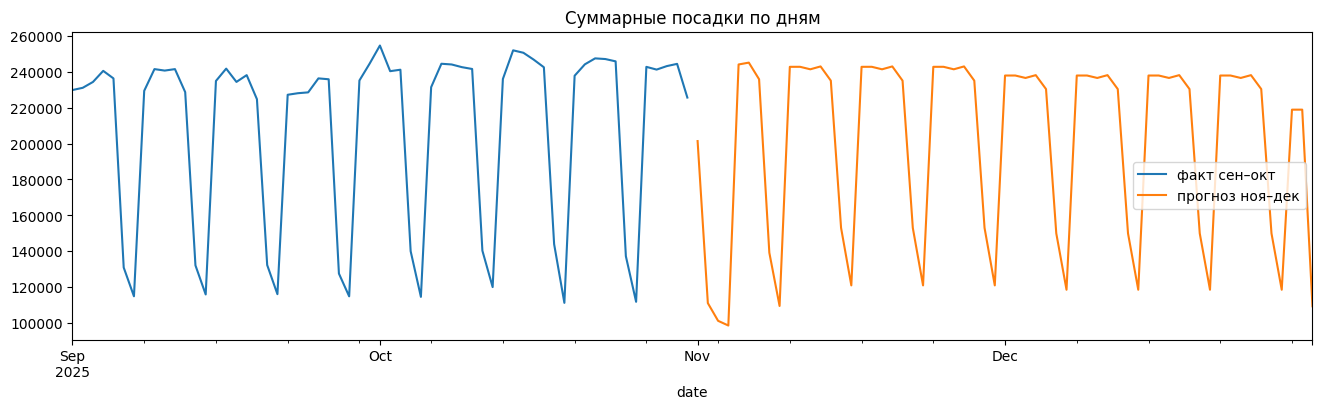

In [23]:
#@title Sanity-check: прогноз vs последние недели истории
hist_w = df[df.date >= "2025-09-01"].set_index("date").boardings.resample("D").sum()
fc_w = pred.set_index("date").pred.resample("D").sum()
ax = hist_w.plot(figsize=(16, 4), label="факт сен–окт"); fc_w.plot(ax=ax, label="прогноз ноя–дек")
ax.legend(); ax.set_title("Суммарные посадки по дням"); plt.show()

In [24]:
#@title 💾 Сохранение сабмита + валидация формата
def to_submission(pred):
    sub = template[["route", "date", "hour"]].copy()
    sub["date"] = pd.to_datetime(sub["date"])
    sub = sub.merge(pred[["route", "date", "hour", "pred"]], on=["route", "date", "hour"], how="left")
    sub["prediction"] = sub.pred.fillna(0).clip(lower=0).round().astype(int)
    sub["date"] = sub.date.dt.strftime("%Y-%m-%d")
    sub = sub[["route", "date", "hour", "prediction"]]
    # проверки из ТЗ
    assert list(sub.columns) == ["route", "date", "hour", "prediction"]
    assert len(sub) == 14640 and not sub.duplicated(["route", "date", "hour"]).any()
    assert sub.prediction.notna().all() and (sub.prediction >= 0).all()
    assert set(sub.route) == set(ROUTES) and sub.date.min() == FORECAST_START and sub.date.max() == FORECAST_END
    return sub

sub = to_submission(pred)
stamp = time.strftime("%Y%m%d_%H%M")
cv_score = cv.loc["mean", {0.0: "profile", 1.0: "lgb"}.get(BLEND_W, f"blend{BLEND_W}")]
fname = OUT_DIR / f"submission_ml_{stamp}_cv{cv_score:.4f}.csv"
sub.to_csv(fname, sep=";", index=False, encoding="utf-8")
sub.to_csv(OUT_DIR / "submission_latest.csv", sep=";", index=False, encoding="utf-8")
json.dump({"best": BEST, "blend_w": BLEND_W, "cv": cv.round(4).to_dict(), "K_holiday": pm.K_holiday, "K_short": pm.K_short,
           "beta_weather": pm.beta.tolist(), "weather": WEATHER_FOR_FORECAST, "weather_horizon_days": WEATHER_HORIZON_DAYS,
           "ml_feats": ML_FEATS, "ml_rounds": ML_ROUNDS, "origins": len(ORIGINS), "K_WORKING_SATURDAY": K_WORKING_SATURDAY, "K_PRE_NEW_YEAR": K_PRE_NEW_YEAR,
           "K_SEASON": K_SEASON, "ROUTE5_ENABLED": ROUTE5_ENABLED, "leak_test": leak.round(6).to_dict(),
           "stream_wape_score": wape_score(allp.boardings, allp.pred)},
          open(OUT_DIR / f"run_{stamp}.json", "w", encoding="utf-8"), ensure_ascii=False, indent=1, default=str)
print(f"✅ сохранено: {fname}\n   сумма прогноза: {sub.prediction.sum():,} | CV WAPE-score (mean по фолдам): {cv_score:.4f}")
print(sub.head())
if IN_COLAB:
    try:
        from google.colab import files; files.download(str(fname))
    except Exception as e:
        print("download:", e)

✅ сохранено: /content/drive/MyDrive/mostrans/submissions/submission_ml_20260925_1645_cv0.8935.csv
   сумма прогноза: 12,266,977 | CV WAPE-score (mean по фолдам): 0.8935
   route        date  hour  prediction
0      1  2025-11-01     0           2
1      1  2025-11-01     1           0
2      1  2025-11-01     2           0
3      1  2025-11-01     3           0
4      1  2025-11-01     4           6


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>